In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('./dataset/StudentsPerformance.csv')
df.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [3]:
print(f"Shape of the dataset is: {df.shape}\n\n")


Shape of the dataset is: (1000, 8)




In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [5]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [6]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [14]:
duplicates = df.duplicated().sum() # stores total number of duplicate rows
print(f"Number of duplicate rows: {duplicates}")

# Rename columns to remove spaces
df.columns = [col.replace(' ', '_').replace('/', '_') for col in df.columns]

# Create a Total Score and Average Score column
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average_score'] = df['total_score'] / 3

print("Data Cleaning Complete. New columns added.")

df.head(10)

Number of duplicate rows: 0
Data Cleaning Complete. New columns added.


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333
5,female,group B,associate's degree,standard,none,71,83,78,232,77.333333
6,female,group B,some college,standard,completed,88,95,92,275,91.666667
7,male,group B,some college,free/reduced,none,40,43,39,122,40.666667
8,male,group D,high school,free/reduced,completed,64,64,67,195,65.000000
9,female,group B,high school,free/reduced,none,38,60,50,148,49.333333


# Q1. Distribution: How are the scores spread?

#### This helps identify if the exams were too hard or too easy.


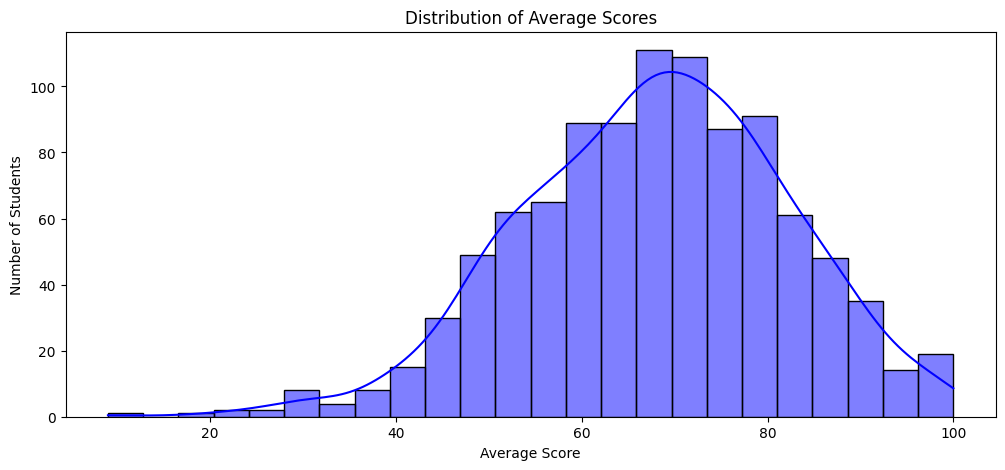

In [18]:
plt.figure(figsize=(12, 5))
sns.histplot(df['average_score'], kde=True, color='blue')
plt.title('Distribution of Average Scores')
plt.xlabel('Average Score')
plt.ylabel('Number of Students')
plt.show()
# Insight: If the curve is bell-shaped, the data is normally distributed.

# Q2 Outliers: Identifying Underperformers

#### We use a Boxplot to see if any students are "statistically distant" from the rest.


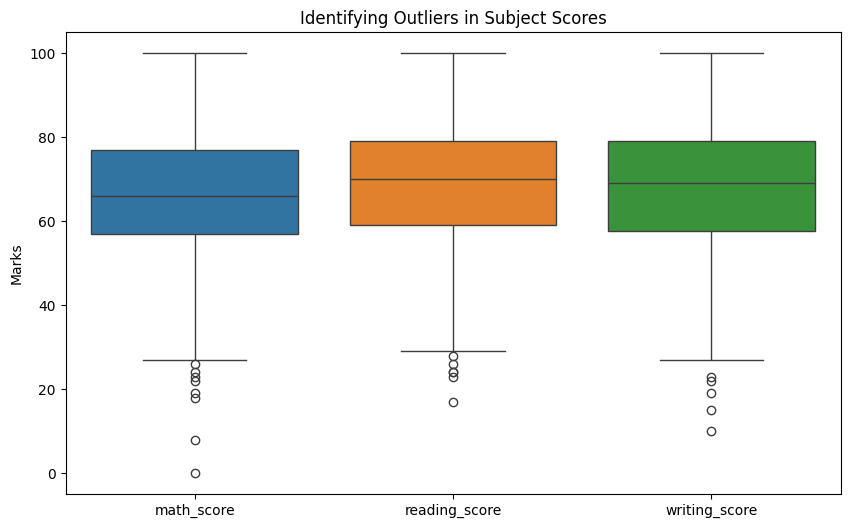

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['math_score', 'reading_score', 'writing_score']])
plt.title('Identifying Outliers in Subject Scores')
plt.ylabel('Marks')
plt.show()
# Insight: Dots at the bottom indicate students who scored significantly lower than the average.

In [19]:
Q1 = df['math_score'].quantile(0.25)
Q3 = df['math_score'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

df[df['math_score'] >= lower_bound]['math_score'].min()

np.int64(27)

# Q3. Relationships: Categorical Impacts

#### Does the parent's education or the prep course actually matter?


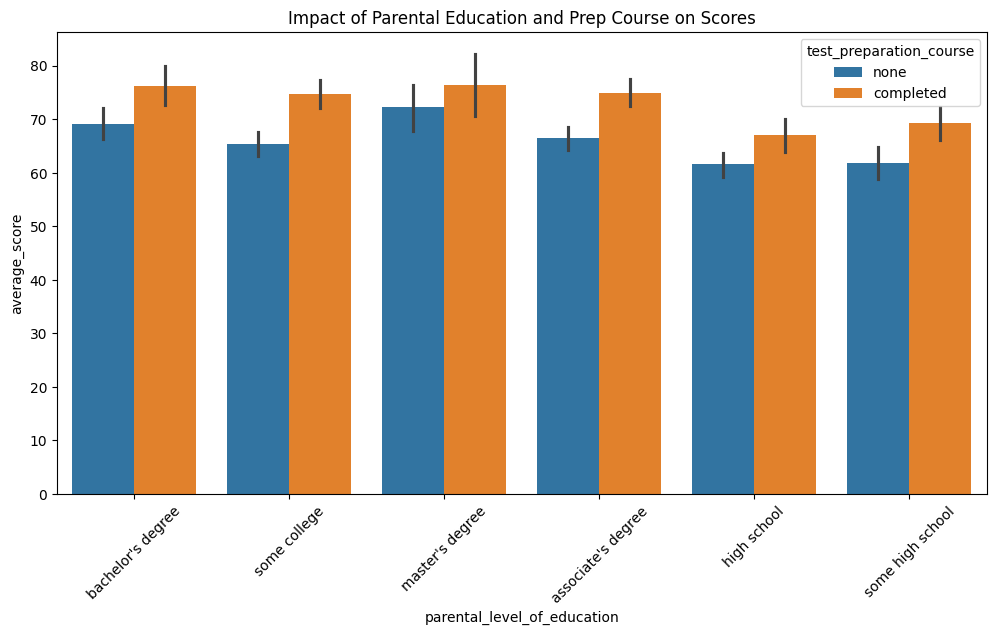

In [10]:
plt.figure(figsize=(12, 6))
sns.barplot(x='parental_level_of_education', y='average_score',
            hue='test_preparation_course', data=df)
plt.xticks(rotation=45)
plt.title('Impact of Parental Education and Prep Course on Scores')
plt.show()

# Q4. Correlation: The Writing-Reading Connection

#### We check if performing well in one subject predicts another.

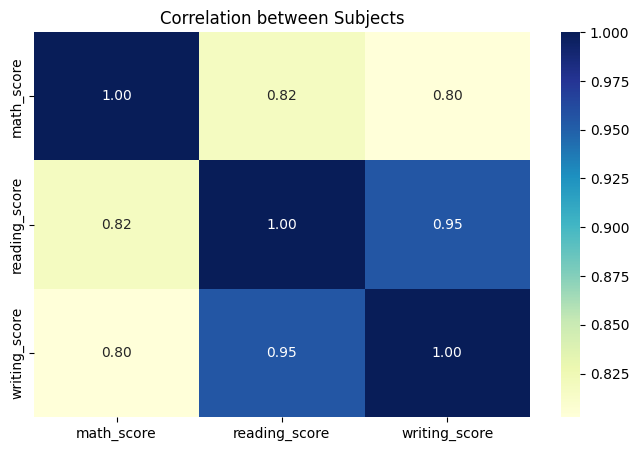

In [11]:
plt.figure(figsize=(8, 5))
correlation = df[['math_score', 'reading_score', 'writing_score']].corr()
sns.heatmap(correlation, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation between Subjects')
plt.show()
# Insight: Usually, Reading and Writing have a very high correlation (>0.9).

# Q5. How does student performance vary by gender across different subjects, and what does the distribution of these scores look like?

#### This question aims to understand not just the average difference, but also the spread, density, and consistency of scores for both male and female students.

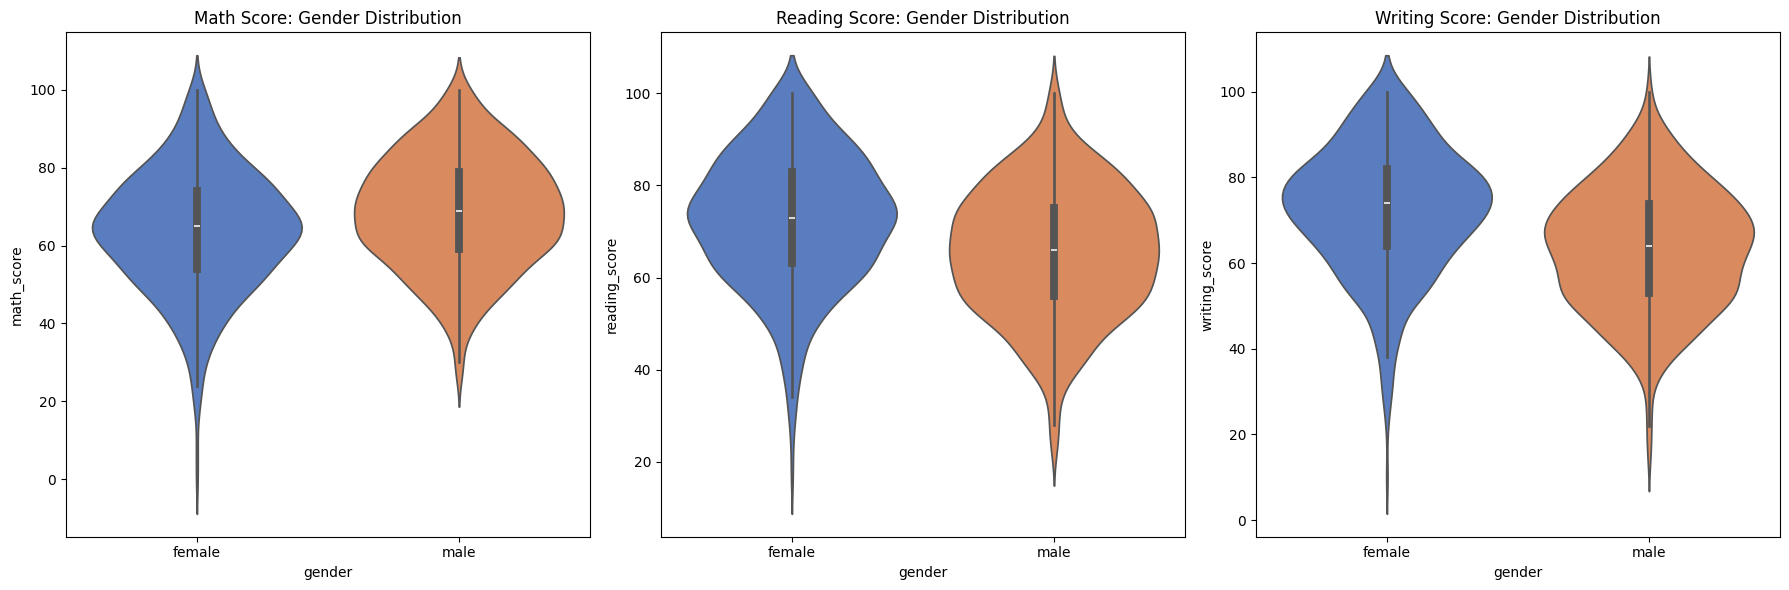

In [12]:
# Create a figure with three subplots for each subject
# We use axes[0], axes[1], etc., to place plots in specific columns
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Math Score Distribution by Gender
# Fix: Added 'hue=gender', 'legend=False', and 'palette'
sns.violinplot(ax=axes[0], x='gender', y='math_score', data=df,
               hue='gender', palette='muted', legend=False)
axes[0].set_title('Math Score: Gender Distribution')

# 2. Reading Score Distribution by Gender
sns.violinplot(ax=axes[1], x='gender', y='reading_score', data=df,
               hue='gender', palette='muted', legend=False)
axes[1].set_title('Reading Score: Gender Distribution')

# 3. Writing Score Distribution by Gender
sns.violinplot(ax=axes[2], x='gender', y='writing_score', data=df,
               hue='gender', palette='muted', legend=False)
axes[2].set_title('Writing Score: Gender Distribution')

plt.tight_layout()
plt.show()